# 🛠️ HƯỚNG DẪN HUẤN LUYỆN MÔ HÌNH (Dành cho Người 3 - XGBoost - Minh)

**Quy định chung của nhóm (Trưởng nhóm yêu cầu):**
1. Tất cả thành viên phải copy file template này thành file riêng của mình (VD: `05B_XGBoost_Minh.ipynb`).
2. **KHÔNG** được thay đổi phần 1 (Load Data) và phần 2 (Chia Train/Test) để đảm bảo mọi người cùng thi trên một bộ dữ liệu.
3. Tất cả phải sử dụng hàm `evaluate_model` ở phần 3 để in ra kết quả cuối cùng (F1, Recall, Precision).
4. Phần 4 là khu vực làm việc riêng của từng người.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Load file từ đường dẫn gốc như hệ thống cung cấp
df = pd.read_csv('/gym_churn_master_final.csv')

# Xóa các cột định danh không có ý nghĩa dự báo
df_ml = df.drop(columns=['short_p_id', 'customer_postal'])

# Chuyển đổi các biến phân loại (Categorical) thành biến giả (Dummy/One-Hot)
df_ml = pd.get_dummies(df_ml, columns=['gender', 'main_density_class'], drop_first=True)

print(f"Kích thước dữ liệu sau khi chuẩn bị: {df_ml.shape}")

Kích thước dữ liệu sau khi chuẩn bị: (6327, 22)


## 2. Chia Dữ Liệu (Train / Test Split)
🚨 **LƯU Ý:** Tuyệt đối không sửa `random_state=42` để đảm bảo kết quả đồng nhất cả nhóm.

In [ ]:
# 2. Chia Dữ Liệu (Train / Test Split)
# LƯU Ý: Loại bỏ 'recency' để tránh hiện tượng Data Leakage (Rò rỉ dữ liệu)
# Giữ nguyên random_state=42 theo quy định của nhóm

import pandas as pd
from sklearn.model_selection import train_test_split

# Tách biến mục tiêu (y) và biến đặc trưng (X)
X = df_ml.drop(columns=['is_churn', 'recency'])
y = df_ml['is_churn']

# Chia tập Train (80%) và Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Số lượng tập Train: {X_train.shape[0]} dòng")
print(f"Số lượng tập Test: {X_test.shape[0]} dòng")
print("\nTỷ lệ Churn trong tập Train:")
print(y_train.value_counts(normalize=True))

Số lượng tập Train: 5061 dòng
Số lượng tập Test: 1266 dòng

Tỷ lệ Churn trong tập Train:
is_churn
1    0.781466
0    0.218534
Name: proportion, dtype: float64


## 3. Hàm Đánh Giá Chung Cho Cả Nhóm
Hàm này dùng để in ra các chỉ số metric và vẽ Confusion Matrix một cách thống nhất.

In [ ]:
def evaluate_model(model_name, y_true, y_pred):
    print(f"\n{'='*40}")
    print(f" KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH: {model_name}")
    print(f"{'='*40}")
    print("\n1. Phân loại tổng quát (Classification Report):")
    print(classification_report(y_true, y_pred))

    print("2. Chỉ số quan trọng nhất (Macro F1-Score):")
    f1 = f1_score(y_true, y_pred, average='macro')
    print(f"-> {f1:.4f}")

    # Vẽ Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Dự báo: Ở lại', 'Dự báo: Nghỉ'],
                yticklabels=['Thực tế: Ở lại', 'Thực tế: Nghỉ'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

## 4. Khu Vực Làm Việc Riêng (Người 3: Mô hình Gradient Boosting / XGBoost)
*(Phần code huấn luyện mô hình XGBoost cá nhân phục vụ đồ án nhóm)*

### 4.1 Cài đặt thư viện XGBoost (Nếu chưa có)
*(Nếu máy của bạn chưa cài `xgboost`, hãy bỏ chú thích dòng bên dưới để cài đặt)*

In [ ]:
# !pip install xgboost

### 4.2 Huấn luyện mô hình XGBoost Baseline
*   **scale_pos_weight = 3.5**: Dữ liệu gym churn bị mất cân bằng (Churn nhãn 1 chiếm ~78%, Active nhãn 0 chiếm ~22%). Thiết lập tỉ lệ $78/22 \approx 3.5$ giúp mô hình phạt nặng hơn khi dự đoán sai nhóm khách hàng rời bỏ phòng tập.

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:42:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH: XGBoost (Baseline)

1. Phân loại tổng quát (Classification Report):
              precision    recall  f1-score   support

           0       0.99      0.83      0.90       277
           1       0.95      1.00      0.98       989

    accuracy                           0.96      1266
   macro avg       0.97      0.91      0.94      1266
weighted avg       0.96      0.96      0.96      1266

2. Chỉ số quan trọng nhất (Macro F1-Score):
-> 0.9398


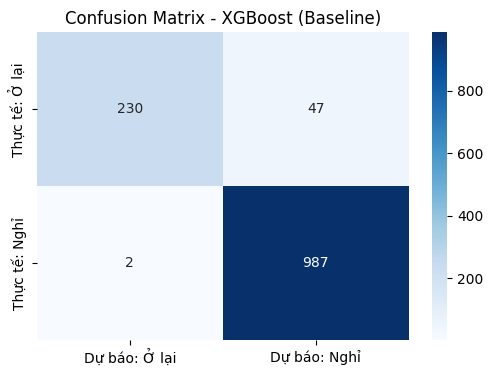

In [ ]:
from xgboost import XGBClassifier

# Khởi tạo XGBoost Baseline với scale_pos_weight tối ưu cho tập dữ liệu mất cân bằng
# Đối với các mô hình cây quyết định (Random Forest, XGBoost), chuẩn hóa dữ liệu (Scaling) là không bắt buộc
xgb_baseline = XGBClassifier(
    scale_pos_weight=3.5,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

# Huấn luyện mô hình trên dữ liệu huấn luyện thô
xgb_baseline.fit(X_train, y_train)

# Dự báo nhãn trên tập kiểm thử (Test)
y_pred_baseline = xgb_baseline.predict(X_test)

# Đánh giá mô hình bằng hàm chung của cả nhóm
evaluate_model("XGBoost (Baseline)", y_test, y_pred_baseline)

### 4.3 Tinh chỉnh siêu tham số bằng GridSearchCV
Sử dụng kỹ thuật quét lưới tham số (GridSearchCV) kết hợp với 5-Fold Cross Validation trên tập Train để tìm ra tổ hợp tham số tốt nhất. Chỉ số mục tiêu cần tối ưu là `f1_macro` như quy định.

Đang tiến hành quét tham số tối ưu (Grid Search CV)...
Fitting 5 folds for each of 36 candidates, totalling 180 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:44:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Tham số tốt nhất tìm được: {'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 100, 'scale_pos_weight': 3.5, 'subsample': 1.0}
Điểm F1-Macro trung bình tốt nhất trên tập CV: 0.9459

 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH: XGBoost (GridSearchCV Optimized)

1. Phân loại tổng quát (Classification Report):
              precision    recall  f1-score   support

           0       1.00      0.83      0.91       277
           1       0.95      1.00      0.98       989

    accuracy                           0.96      1266
   macro avg       0.98      0.91      0.94      1266
weighted avg       0.96      0.96      0.96      1266

2. Chỉ số quan trọng nhất (Macro F1-Score):
-> 0.9407


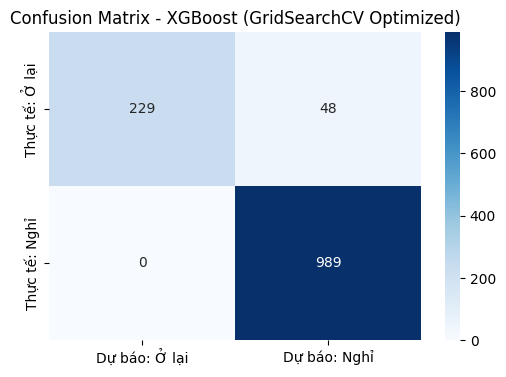

In [ ]:
from sklearn.model_selection import GridSearchCV

# Lưới tham số cần tinh chỉnh được Trưởng nhóm yêu cầu chi tiết trong TEAM_MODELING_GUIDE
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'scale_pos_weight': [3.5]
}

# Khởi tạo GridSearch với tiêu chí f1_macro
grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False),
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    verbose=1,
    n_jobs=-1
)

print("Đang tiến hành quét tham số tối ưu (Grid Search CV)...")
grid_search.fit(X_train, y_train)

# Hiển thị bộ siêu tham số tốt nhất và điểm số tương ứng trên tập Validation
print("\nTham số tốt nhất tìm được:", grid_search.best_params_)
print(f"Điểm F1-Macro trung bình tốt nhất trên tập CV: {grid_search.best_score_:.4f}")

# Lấy mô hình tốt nhất sau khi tối ưu
best_xgb = grid_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)

# Đánh giá mô hình tối ưu trên tập Test độc lập
evaluate_model("XGBoost (GridSearchCV Optimized)", y_test, y_pred_best)

### 4.4 Phân tích Feature Importance (Nhiệm vụ đặc biệt)
Trích xuất độ quan trọng của đặc trưng (`feature_importances_`) từ mô hình XGBoost tốt nhất để tìm ra top 10 đặc trưng ảnh hưởng nhiều nhất đến quyết định rời bỏ phòng tập của học viên.

/tmp/ipykernel_12434/3901794201.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')


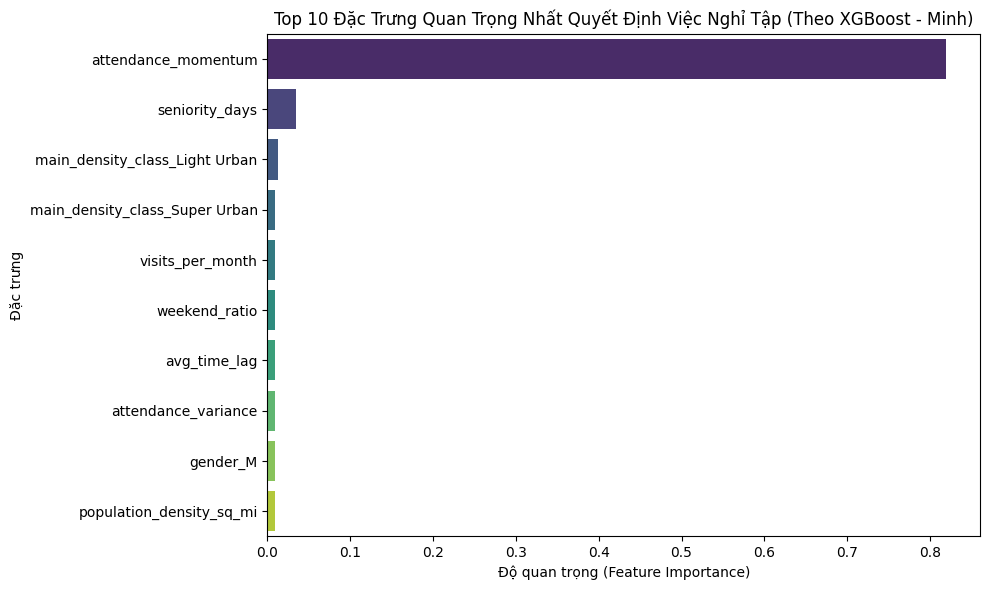

In [ ]:
# Lấy trọng số Feature Importance
importances = best_xgb.feature_importances_
features = X.columns

# Tạo DataFrame để sắp xếp
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Vẽ biểu đồ Top 10 đặc trưng
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')
plt.title('Top 10 Đặc Trưng Quan Trọng Nhất Quyết Định Việc Nghỉ Tập (Theo XGBoost - Minh)')
plt.xlabel('Độ quan trọng (Feature Importance)')
plt.ylabel('Đặc trưng')
plt.tight_layout()
plt.show()

### 4.5 Kết luận và Nhận xét báo cáo cho Trưởng Nhóm
*(Bạn hãy điền nhận xét thực tế từ kết quả chạy được của bạn vào slide và báo cáo)*
1. **Chỉ số Macro F1-Score đạt được:** ... (so sánh với mốc baseline 0.5519 của Trưởng nhóm)
2. **Bộ tham số tối ưu:** `best_params_ =` ...
3. **Top 3 đặc trưng quan trọng nhất:** ...
4. **Nhận xét ngắn gọn:** ...